# 따릉이 자치구 · 시간별 대여량 예측 모델 (코로나 시기 제외)

**입력**: 데이터 준비 노트북(1번)이 만든 `model_data_2022` 폴더

| 구분 | 내용 |
|---|---|
| 입력 X | 자치구, 시간, 요일, 기온, 강수량, 미세먼지, 휴일, 과거 대여량 ... (`features.txt`) |
| 정답 y | 그 자치구 · 그 시간의 대여량 |

**진행 순서**
1. 설정 / 데이터 불러오기
2. [발표용] 코로나 포함 vs 제외 비교 (같은 검증 기간)
3. [발표용] 날씨 없음 vs 날씨 포함 비교
4. 모델 비교 → 모델 선택
5. 학습 모델 → 검증 모델(테스트 평가) → 최종 모델
6. 대여소별 나누기 (자치구 예측 × 대여소 비중)
7. 미래 예측
8. 웹페이지용 저장

In [1]:
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

## 1. 설정

In [2]:
DATA_DIR = "./model_data_2022"      # 1번 노트북이 저장한 폴더
OUTPUT_DIR = "./model_output"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

TARGET = "대여량"

# 트리 모델은 학습 때 못 본 연도(2026년 등)를 제대로 다루지 못해서 '연도'는 뺍니다.
# (연도별 규모 차이는 과거 대여량 변수가 대신 알려줌)
DROP_FEATURES = ["연도"]

WEATHER_COLS = ["평균기온", "최저기온", "최고기온", "일교차", "강수량", "비", "전날강수량", "미세먼지", "초미세먼지"]
WEATHER_BASE = ["평균기온", "최저기온", "최고기온", "강수량", "미세먼지", "초미세먼지"]   # 예보로 받을 값

FORECAST_DAYS = 7          # 미래 예측 일수 (기상청 예보가 있는 기간 정도가 적당)
SHARE_MONTHS = 3           # 대여소 비중을 계산할 최근 개월 수
WEATHER_FORECAST_PATH = "./weather_forecast.csv"   # 기상청 예보 (없으면 평년값 사용)

COMPARE_MAX_ROWS = 300_000  # 비교 단계에서 학습에 쓸 최대 행 수 (속도용)
RANDOM_STATE = 42


def set_korean_font():
    from matplotlib import font_manager
    installed = {f.name for f in font_manager.fontManager.ttflist}
    for font in ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"]:
        if font in installed:
            plt.rcParams["font.family"] = font
            break
    plt.rcParams["axes.unicode_minus"] = False


set_korean_font()


def save_fig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, name), dpi=150)
    plt.show()

### 데이터 불러오기

In [3]:
def read_part(name):
    return pd.read_csv(os.path.join(DATA_DIR, name), parse_dates=["일시", "날짜"], encoding="utf-8-sig")


train = read_part("train.csv")            # 2022~2023 (코로나 제외)
valid = read_part("valid.csv")            # 2024
test = read_part("test.csv")              # 2025
covid = read_part("train_covid.csv")      # 2020~2021 (비교용)

with open(os.path.join(DATA_DIR, "features.txt"), encoding="utf-8") as fp:
    FEATURES = [f for f in fp.read().splitlines() if f and f not in DROP_FEATURES]
FEATURES_NO_WEATHER = [f for f in FEATURES if f not in WEATHER_COLS]

with open(os.path.join(DATA_DIR, "holidays.txt"), encoding="utf-8") as fp:
    HOLIDAYS = pd.to_datetime(fp.read().split())

station = pd.read_csv(os.path.join(DATA_DIR, "대여소_월별시간별.csv"), encoding="utf-8-sig")

all_data = pd.concat([covid, train, valid, test], ignore_index=True)
gu_codes = dict(all_data[["자치구", "자치구코드"]].drop_duplicates().values)

for name, part in [("코로나(비교용)", covid), ("학습", train), ("검증", valid), ("테스트", test)]:
    print(f"{name:10s}: {part['날짜'].min().date()} ~ {part['날짜'].max().date()}  ({len(part):,}행)")
print("입력 변수:", FEATURES)
print("대여소 데이터:", station["연월"].min(), "~", station["연월"].max(),
      f"/ {station.groupby(['자치구', '대여소명']).ngroups}곳")

코로나(비교용)  : 2020-01-08 ~ 2021-12-31  (434,400행)
학습        : 2022-01-01 ~ 2023-12-31  (438,000행)
검증        : 2024-01-01 ~ 2024-12-31  (219,600행)
테스트       : 2025-01-01 ~ 2025-12-31  (219,000행)
입력 변수: ['자치구코드', '월', '요일', '시간', '주말', '공휴일', '쉬는날', '출퇴근시간', '평균기온', '최저기온', '최고기온', '일교차', '강수량', '비', '전날강수량', '미세먼지', '초미세먼지', '전날같은시간', '지난주같은시간', '최근7일같은시간평균', '전날총대여량']
대여소 데이터: 2024-01 ~ 2025-12 / 2882곳


### [발표용] 기간 나누기 그림

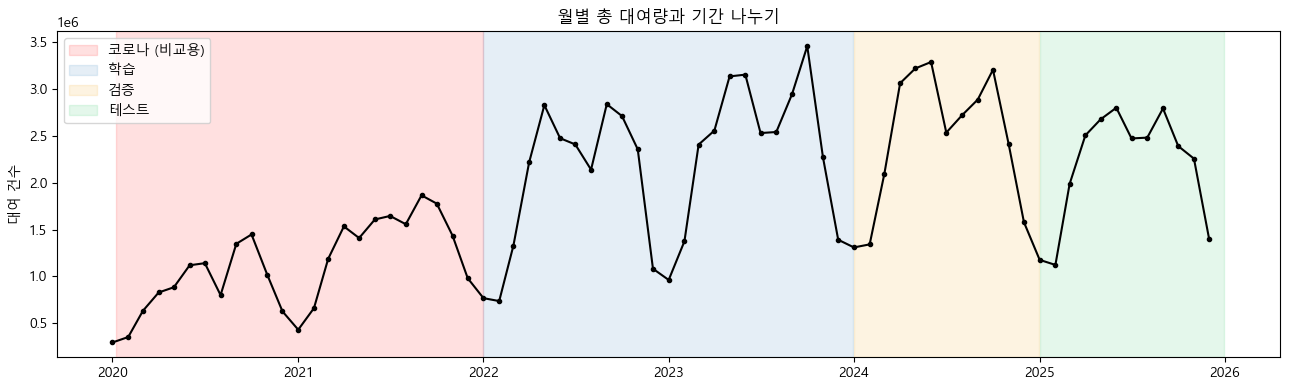

In [4]:
monthly = all_data.groupby(pd.Grouper(key="일시", freq="MS"))[TARGET].sum()

plt.figure(figsize=(13, 4))
plt.plot(monthly.index, monthly.values, color="black", marker=".")
for part, color, label in [(covid, "red", "코로나 (비교용)"), (train, "#2b7bba", "학습"),
                           (valid, "#f59e0b", "검증"), (test, "#22c55e", "테스트")]:
    plt.axvspan(part["날짜"].min(), part["날짜"].max(), color=color, alpha=0.12, label=label)
plt.title("월별 총 대여량과 기간 나누기")
plt.ylabel("대여 건수")
plt.legend(loc="upper left")
save_fig("01_기간나누기.png")

## 공통 함수: 학습 / 예측 / 평가
- **MAE**: 한 시간에 평균 몇 건 틀렸나 (작을수록 좋음)
- **RMSE**: 크게 틀린 시간에 벌점을 더 줌 (작을수록 좋음)
- **R2**: 1에 가까울수록 좋음
- **하루 MAPE**: 자치구 하루 합계 기준 몇 % 틀렸나 (발표용으로 이해하기 쉬움)

In [5]:
def fit_model(model, data, features, max_rows=None):
    if max_rows and len(data) > max_rows:
        data = data.sample(max_rows, random_state=RANDOM_STATE)
    model.fit(data[features], data[TARGET])
    return model


def predict(model, data, features):
    return np.clip(model.predict(data[features]), 0, None)   # 음수는 0으로


def evaluate(data, pred):
    y = data[TARGET]
    day = data[["날짜", "자치구", TARGET]].assign(pred=pred).groupby(["날짜", "자치구"]).sum()
    day = day[day[TARGET] > 0]
    return {
        "시간 MAE": mean_absolute_error(y, pred),
        "시간 RMSE": np.sqrt(mean_squared_error(y, pred)),
        "R2": r2_score(y, pred),
        "하루 MAPE(%)": ((day["pred"] - day[TARGET]).abs() / day[TARGET]).mean() * 100,
    }


def daily_total(data, pred):
    """날짜별 서울 전체 합계 (실제, 예측)"""
    return data[["날짜", TARGET]].assign(pred=pred).groupby("날짜").sum()


def bar_compare(table, title, filename, colors):
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, metric in zip(axes, ["시간 MAE", "시간 RMSE", "하루 MAPE(%)"]):
        bars = ax.bar(table.index, table[metric], color=colors)
        ax.bar_label(bars, fmt="%.2f")
        ax.set_title(metric + " (낮을수록 좋음)")
    plt.suptitle(title)
    save_fig(filename)

## 2. [발표용] 코로나 포함 vs 제외
같은 모델(HistGradientBoosting), **같은 검증 기간(2024년)** 에서 학습 데이터만 다르게 해서 비교합니다.
- 코로나 포함: 2020~2023 학습
- 코로나 제외: 2022~2023 학습

In [6]:
hgb = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, random_state=RANDOM_STATE)
train_with_covid = pd.concat([covid, train], ignore_index=True)

model_in = fit_model(clone(hgb), train_with_covid, FEATURES, COMPARE_MAX_ROWS)
model_out = fit_model(clone(hgb), train, FEATURES, COMPARE_MAX_ROWS)
pred_in = predict(model_in, valid, FEATURES)
pred_out = predict(model_out, valid, FEATURES)

covid_table = pd.DataFrame({"코로나 포함": evaluate(valid, pred_in), "코로나 제외": evaluate(valid, pred_out)}).T
print(covid_table.round(3).to_string())

        시간 MAE  시간 RMSE     R2  하루 MAPE(%)
코로나 포함  26.006   49.069  0.909      15.907
코로나 제외  25.781   48.196  0.913      16.572


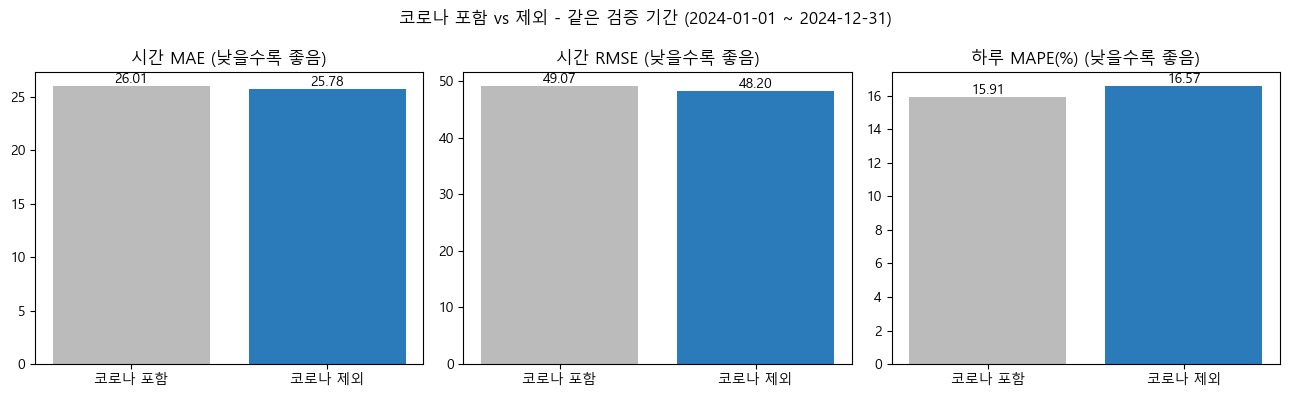

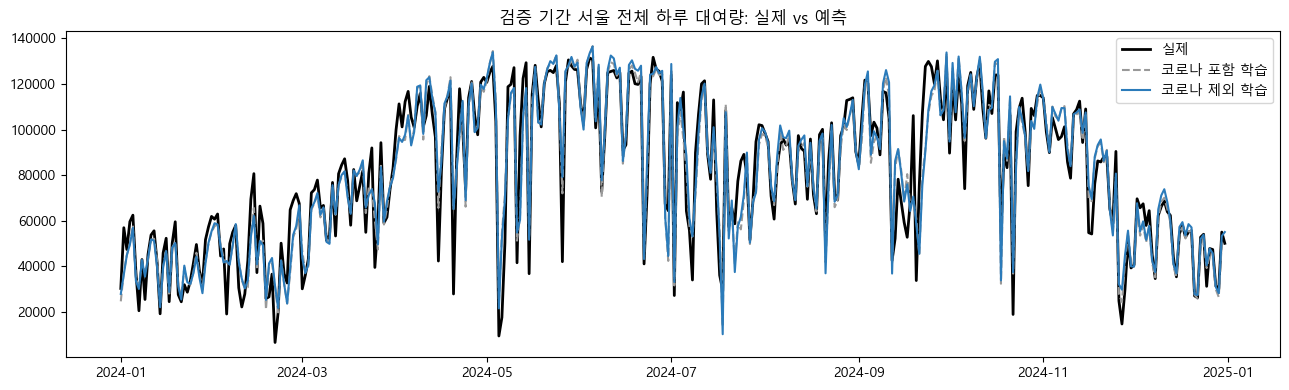

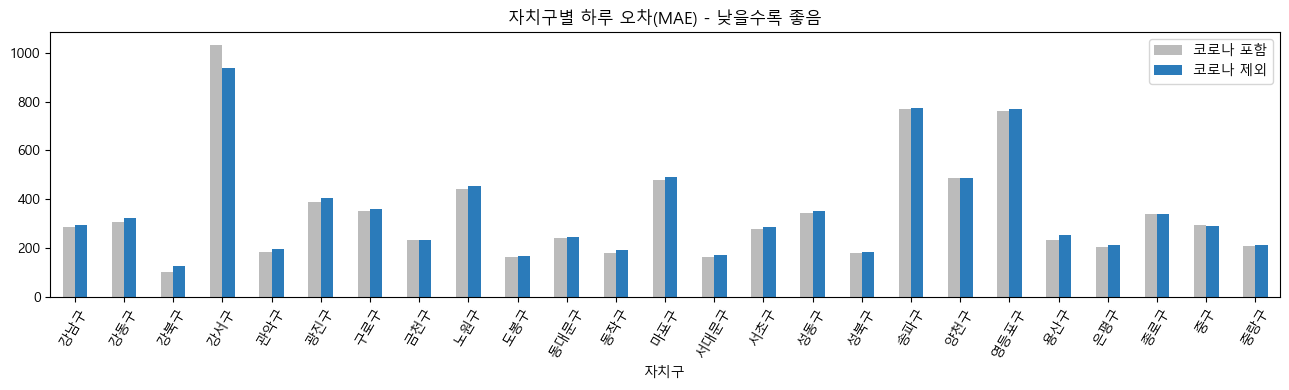

In [7]:
GRAY_BLUE = ["#bbbbbb", "#2b7bba"]
bar_compare(covid_table, f"코로나 포함 vs 제외 - 같은 검증 기간 ({valid['날짜'].min().date()} ~ {valid['날짜'].max().date()})",
            "02_코로나_포함vs제외_지표.png", GRAY_BLUE)

t_in, t_out = daily_total(valid, pred_in), daily_total(valid, pred_out)
plt.figure(figsize=(13, 4))
plt.plot(t_in.index, t_in[TARGET], color="black", lw=2, label="실제")
plt.plot(t_in.index, t_in["pred"], color="#999999", ls="--", label="코로나 포함 학습")
plt.plot(t_out.index, t_out["pred"], color="#2b7bba", label="코로나 제외 학습")
plt.title("검증 기간 서울 전체 하루 대여량: 실제 vs 예측")
plt.legend()
save_fig("03_코로나_포함vs제외_예측선.png")

gu_err = valid[["자치구", "날짜", TARGET]].assign(포함=pred_in, 제외=pred_out).groupby(["자치구", "날짜"]).sum()
gu_mae = pd.DataFrame({
    "코로나 포함": (gu_err["포함"] - gu_err[TARGET]).abs().groupby("자치구").mean(),
    "코로나 제외": (gu_err["제외"] - gu_err[TARGET]).abs().groupby("자치구").mean(),
})
gu_mae.plot(kind="bar", figsize=(13, 4), color=GRAY_BLUE)
plt.title("자치구별 하루 오차(MAE) - 낮을수록 좋음")
plt.xticks(rotation=60)
save_fig("04_코로나_포함vs제외_자치구별.png")

## 3. [발표용] 날씨 없음 vs 날씨 포함
데이터 준비 노트북의 날씨 분석 결과(비 오면 이용량 감소, 18~21℃에서 가장 많음)가 **예측에도 도움이 되는지** 확인합니다.
둘 다 코로나 제외 데이터, 같은 검증 기간입니다.

In [8]:
model_no_w = fit_model(clone(hgb), train, FEATURES_NO_WEATHER, COMPARE_MAX_ROWS)
pred_no_w = predict(model_no_w, valid, FEATURES_NO_WEATHER)

weather_table = pd.DataFrame({"날씨 없음": evaluate(valid, pred_no_w), "날씨 포함": evaluate(valid, pred_out)}).T
print(weather_table.round(3).to_string())

       시간 MAE  시간 RMSE     R2  하루 MAPE(%)
날씨 없음  31.714   63.513  0.848      30.890
날씨 포함  25.781   48.196  0.913      16.572


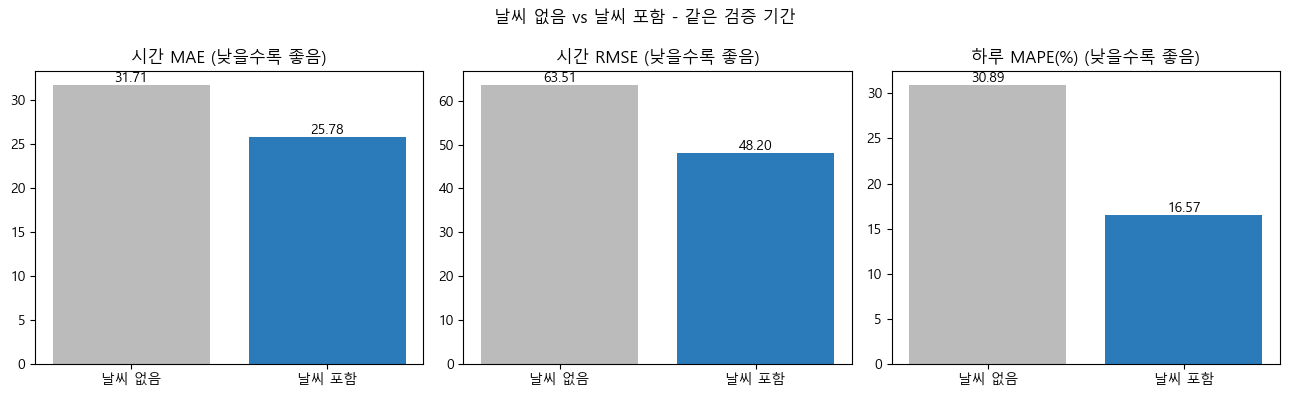

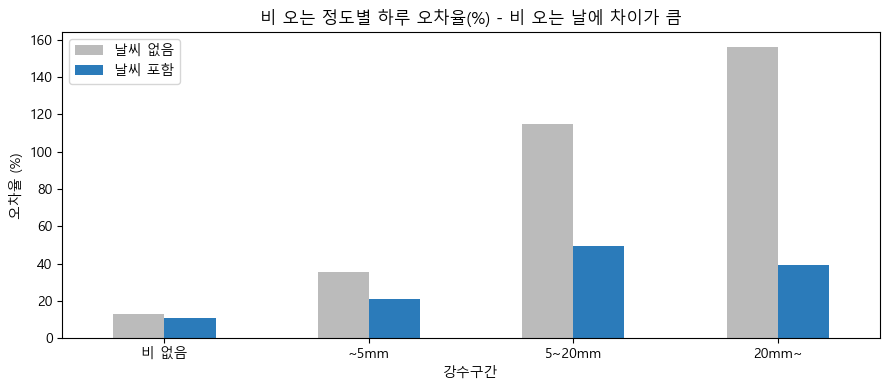

In [9]:
bar_compare(weather_table, "날씨 없음 vs 날씨 포함 - 같은 검증 기간", "05_날씨_없음vs포함_지표.png", GRAY_BLUE)

# 비 오는 정도별 하루 오차율
day_w = (valid[["날짜", "자치구", "강수량", TARGET]]
         .assign(없음=pred_no_w, 포함=pred_out)
         .groupby(["날짜", "자치구"])
         .agg(강수량=("강수량", "first"), 실제=(TARGET, "sum"), 없음=("없음", "sum"), 포함=("포함", "sum")))
day_w = day_w[day_w["실제"] > 0]
day_w["강수구간"] = pd.cut(day_w["강수량"], bins=[-1, 0, 5, 20, 1000], labels=["비 없음", "~5mm", "5~20mm", "20mm~"])
rain_err = pd.DataFrame({
    "날씨 없음": ((day_w["없음"] - day_w["실제"]).abs() / day_w["실제"]).groupby(day_w["강수구간"], observed=True).mean() * 100,
    "날씨 포함": ((day_w["포함"] - day_w["실제"]).abs() / day_w["실제"]).groupby(day_w["강수구간"], observed=True).mean() * 100,
})
rain_err.plot(kind="bar", figsize=(9, 4), color=GRAY_BLUE, rot=0)
plt.title("비 오는 정도별 하루 오차율(%) - 비 오는 날에 차이가 큼")
plt.ylabel("오차율 (%)")
save_fig("06_날씨_비오는날_오차.png")

## 4. 모델 비교 → 모델 선택
모두 **코로나 제외 학습 데이터 + 날씨 포함**으로 학습하고, 검증 기간으로 평가합니다.
- 기준모델: 지난주 같은 시간 값을 그대로 쓰는 방법. 다른 모델은 이것보다 좋아야 의미가 있습니다.
- **시간 MAE가 가장 낮은 모델**을 선택합니다.

In [10]:
models = {
    "선형회귀(Ridge)": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "랜덤포레스트": RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=10,
                                     n_jobs=-1, random_state=RANDOM_STATE),
    "그래디언트부스팅(HGB)": HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05,
                                                     random_state=RANDOM_STATE),
}

BASELINE = "기준모델(지난주 같은 시간)"
results = {BASELINE: evaluate(valid, valid["지난주같은시간"].values)}
trained = {}
for name, model in models.items():
    print("학습 중:", name)
    trained[name] = fit_model(clone(model), train, FEATURES, COMPARE_MAX_ROWS)
    results[name] = evaluate(valid, predict(trained[name], valid, FEATURES))

compare_table = pd.DataFrame(results).T.sort_values("시간 MAE")
print(compare_table.round(3).to_string())

best_name = compare_table.drop(index=BASELINE)["시간 MAE"].idxmin()
print("\n✅ 선택된 모델:", best_name)

학습 중: 선형회귀(Ridge)
학습 중: 랜덤포레스트
학습 중: 그래디언트부스팅(HGB)
                 시간 MAE  시간 RMSE     R2  하루 MAPE(%)
그래디언트부스팅(HGB)    25.781   48.196  0.913      16.572
랜덤포레스트           26.036   50.441  0.904      17.513
선형회귀(Ridge)      37.534   69.993  0.816      25.020
기준모델(지난주 같은 시간)  44.763   93.926  0.668      43.015

✅ 선택된 모델: 그래디언트부스팅(HGB)


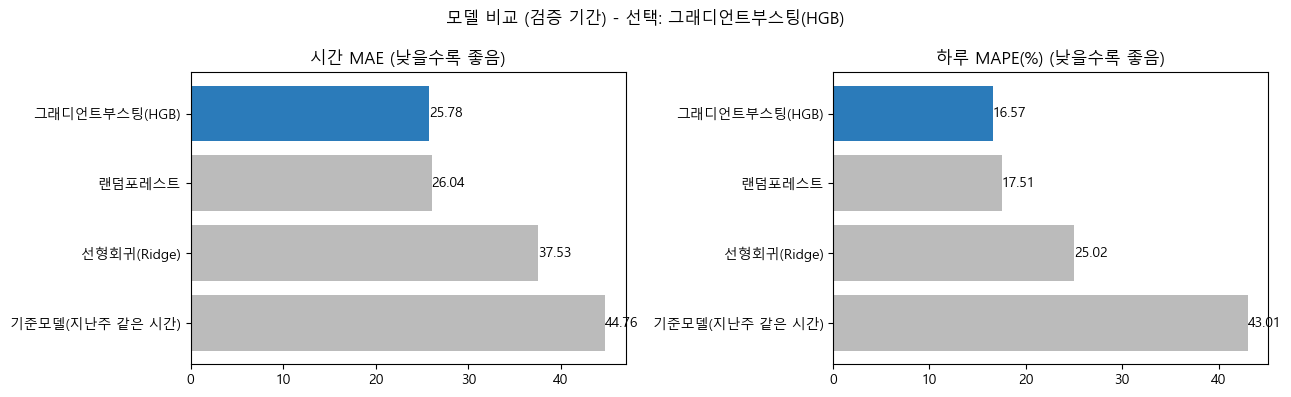

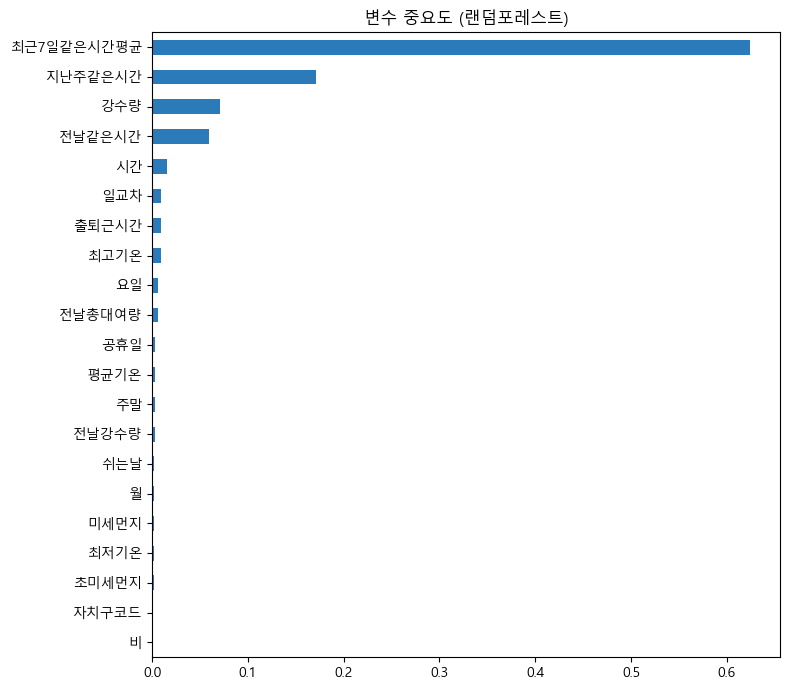

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric in zip(axes, ["시간 MAE", "하루 MAPE(%)"]):
    values = compare_table[metric].sort_values()
    bars = ax.barh(values.index, values.values,
                   color=["#2b7bba" if n == best_name else "#bbbbbb" for n in values.index])
    ax.bar_label(bars, fmt="%.2f")
    ax.invert_yaxis()
    ax.set_title(metric + " (낮을수록 좋음)")
plt.suptitle(f"모델 비교 (검증 기간) - 선택: {best_name}")
save_fig("07_모델비교.png")

# 어떤 변수가 중요했는지 (랜덤포레스트 기준)
importance = pd.Series(trained["랜덤포레스트"].feature_importances_, index=FEATURES).sort_values()
importance.plot(kind="barh", figsize=(8, 7), color="#2b7bba")
plt.title("변수 중요도 (랜덤포레스트)")
save_fig("08_변수중요도.png")

## 5. 학습 모델 / 검증 모델 / 최종 모델
| 이름 | 학습 데이터 | 평가 | 용도 |
|---|---|---|---|
| 학습 모델 | 2022~2023 | 검증(2024) | 모델 고르기 (4번에서 완료) |
| 검증 모델 | 2022~2024 | **테스트(2025)** | 최종 성능 확인 (발표용 점수) |
| 최종 모델 | 2022~2025 | - | 미래 예측, 웹 |

세 모델 모두 **코로나 시기 제외**입니다.

In [12]:
# (1) 학습 모델
train_model = trained[best_name]
joblib.dump(train_model, os.path.join(OUTPUT_DIR, "model_1_train.pkl"))

# (2) 검증 모델: 학습 + 검증 기간으로 다시 학습 → 테스트 평가
valid_model = fit_model(clone(models[best_name]), pd.concat([train, valid]), FEATURES)
test_pred = predict(valid_model, test, FEATURES)
joblib.dump(valid_model, os.path.join(OUTPUT_DIR, "model_2_valid.pkl"))

test_table = pd.DataFrame({
    BASELINE: evaluate(test, test["지난주같은시간"].values),
    best_name: evaluate(test, test_pred),
}).T
print("테스트 기간 성능")
print(test_table.round(3).to_string())

테스트 기간 성능
                 시간 MAE  시간 RMSE     R2  하루 MAPE(%)
기준모델(지난주 같은 시간)  41.497   87.851  0.650      48.257
그래디언트부스팅(HGB)    23.802   45.658  0.906      17.745


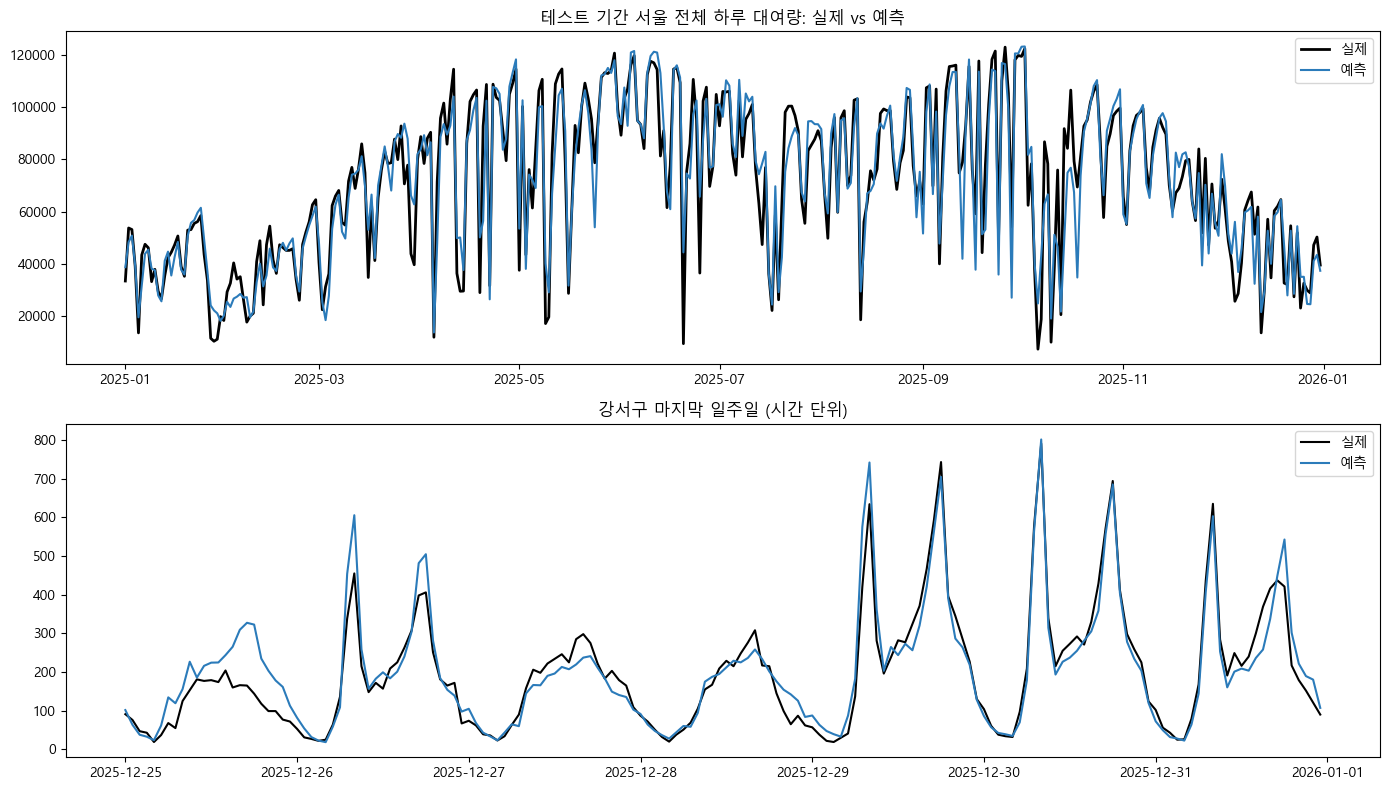

In [13]:
t_test = daily_total(test, test_pred)
top_gu = test.groupby("자치구")[TARGET].sum().idxmax()
week = test.assign(pred=test_pred)
week = week[week["자치구"] == top_gu].tail(24 * 7)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(t_test.index, t_test[TARGET], color="black", lw=2, label="실제")
axes[0].plot(t_test.index, t_test["pred"], color="#2b7bba", label="예측")
axes[0].set_title("테스트 기간 서울 전체 하루 대여량: 실제 vs 예측")
axes[0].legend()
axes[1].plot(week["일시"], week[TARGET], color="black", label="실제")
axes[1].plot(week["일시"], week["pred"], color="#2b7bba", label="예측")
axes[1].set_title(f"{top_gu} 마지막 일주일 (시간 단위)")
axes[1].legend()
save_fig("09_테스트결과.png")

In [14]:
# (3) 최종 모델: 코로나 제외 전체 기간
final_data = pd.concat([train, valid, test], ignore_index=True)
final_model = fit_model(clone(models[best_name]), final_data, FEATURES)
joblib.dump(final_model, os.path.join(OUTPUT_DIR, "model_3_final.pkl"))
print("저장 완료: model_1_train.pkl, model_2_valid.pkl, model_3_final.pkl")

저장 완료: model_1_train.pkl, model_2_valid.pkl, model_3_final.pkl


## 6. 대여소별 나누기
모델은 **자치구 × 시간**을 예측합니다. 대여소 값은 이렇게 만듭니다.

`대여소 예측 = 자치구 예측 × 그 대여소의 비중`

- 비중 = 최근 `SHARE_MONTHS`개월 동안 그 구 대여량 중 그 대여소가 차지한 비율
- 평일 / 쉬는날, 시간대마다 따로 계산 (역 앞은 출퇴근, 공원은 주말 오후 비중이 큼)
- 이렇게 하면 **대여소 값을 다 더하면 자치구 값과 같습니다.**

In [15]:
def make_station_share(station, months, before=None):
    """최근 몇 개월의 대여소 비중 (before 가 있으면 그 달 이전만 사용)"""
    data = station if before is None else station[station["연월"] < before]
    recent = sorted(data["연월"].unique())[-months:]
    data = data[data["연월"].isin(recent)]
    s = data.groupby(["자치구", "대여소명", "쉬는날", "시간"])["대여량"].sum().reset_index()
    s["비중"] = s["대여량"] / s.groupby(["자치구", "쉬는날", "시간"])["대여량"].transform("sum")
    return s[["자치구", "대여소명", "쉬는날", "시간", "비중"]]


def split_to_stations(gu_pred, share):
    """gu_pred: 일시, 날짜, 자치구, 쉬는날, 시간, pred → 대여소별 예측"""
    out = gu_pred.merge(share, on=["자치구", "쉬는날", "시간"], how="inner")
    out["pred"] = out["pred"] * out["비중"]
    return out.drop(columns="비중")

### 대여소 예측이 맞는지 확인 (테스트 기간)
테스트 기간 **이전** 비중으로 나눈 값과, 실제 대여소별 월 대여량을 비교합니다.

대여소 월 대여량 오차율(WAPE): 15.2%
대여소 월 대여량 평균 오차(MAE): 118.2건


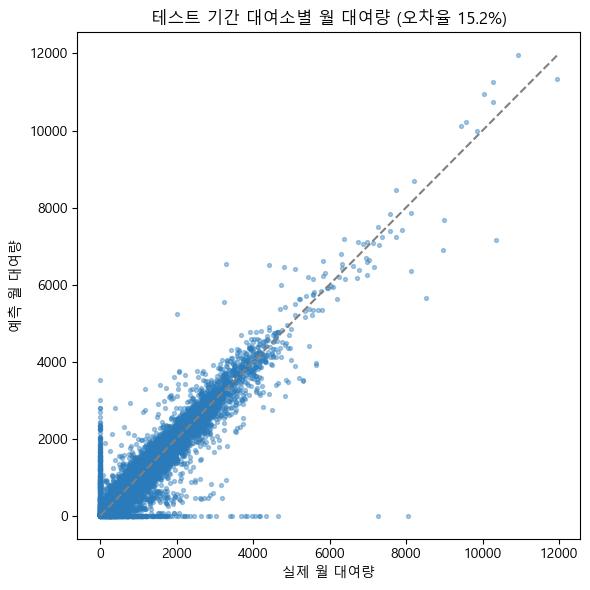

In [16]:
test_month0 = test["날짜"].min().strftime("%Y-%m")
if station["연월"].min() < test_month0:
    share_before = make_station_share(station, SHARE_MONTHS, before=test_month0)
    gu_test = test[["일시", "날짜", "자치구", "쉬는날", "시간"]].assign(pred=test_pred)
    st_test = split_to_stations(gu_test, share_before)
    st_test["연월"] = st_test["날짜"].dt.strftime("%Y-%m")
    st_pred = st_test.groupby(["연월", "자치구", "대여소명"])["pred"].sum()
    st_true = station[station["연월"] >= test_month0].groupby(["연월", "자치구", "대여소명"])["대여량"].sum()
    st_cmp = pd.concat([st_true.rename("실제"), st_pred.rename("예측")], axis=1).fillna(0)

    wape = (st_cmp["예측"] - st_cmp["실제"]).abs().sum() / st_cmp["실제"].sum() * 100
    print(f"대여소 월 대여량 오차율(WAPE): {wape:.1f}%")
    print(f"대여소 월 대여량 평균 오차(MAE): {(st_cmp['예측'] - st_cmp['실제']).abs().mean():.1f}건")

    plt.figure(figsize=(6, 6))
    plt.scatter(st_cmp["실제"], st_cmp["예측"], s=8, alpha=0.4, color="#2b7bba")
    lim = st_cmp.max().max()
    plt.plot([0, lim], [0, lim], color="gray", ls="--")
    plt.xlabel("실제 월 대여량")
    plt.ylabel("예측 월 대여량")
    plt.title(f"테스트 기간 대여소별 월 대여량 (오차율 {wape:.1f}%)")
    save_fig("10_대여소_예측확인.png")
else:
    print("테스트 기간 이전의 대여소 데이터가 없어 확인을 건너뜁니다. (1번 노트북 STATION_YEARS 를 늘려주세요)")

## 7. 미래 예측
과거 대여량 변수 중 가장 가까운 값이 **24시간 전**이라서, **하루씩 예측하고 그 값을 다음 날 변수로 다시 사용**합니다.

미래 날씨
- `weather_forecast.csv`(기상청 예보)가 있으면 예보를 사용
  - 컬럼: 날짜, 자치구, 평균기온, 최저기온, 최고기온, 강수량, 미세먼지, 초미세먼지
- 없는 날은 **평년값**(과거 같은 날짜 평균, 비는 "안 옴"으로 가정)을 사용

In [17]:
def make_weather_normals(weather_daily):
    """자치구 · 월-일별 평년값 (강수량은 중앙값 → 대부분 0)"""
    w = weather_daily.copy()
    w["월일"] = w["날짜"].dt.strftime("%m-%d")
    normals = w.groupby(["자치구", "월일"])[WEATHER_BASE].mean()
    normals["강수량"] = w.groupby(["자치구", "월일"])["강수량"].median()
    return normals.reset_index()


def fill_future_weather(normals, dates, gus, last_rain, forecast=None):
    """미래 날짜의 날씨 표 (예보 > 평년값 순서로 사용)"""
    grid = pd.MultiIndex.from_product([dates, gus], names=["날짜", "자치구"]).to_frame(index=False)
    grid["월일"] = grid["날짜"].dt.strftime("%m-%d")
    w = grid.merge(normals, on=["자치구", "월일"], how="left").drop(columns="월일")
    w["출처"] = "평년값"
    if forecast is not None and len(forecast) > 0:
        fc = forecast.set_index(["날짜", "자치구"])
        w = w.set_index(["날짜", "자치구"])
        common = w.index.intersection(fc.index)
        cols = [c for c in WEATHER_BASE if c in fc.columns]
        w.loc[common, cols] = fc.loc[common, cols].values
        w.loc[common, "출처"] = "예보"
        w = w.reset_index()
    w = w.sort_values(["자치구", "날짜"])
    w["일교차"] = w["최고기온"] - w["최저기온"]
    w["비"] = (w["강수량"] > 0).astype(int)
    w["전날강수량"] = w.groupby("자치구")["강수량"].shift(1)
    first = w["날짜"] == w["날짜"].min()
    w.loc[first, "전날강수량"] = w.loc[first, "자치구"].map(last_rain).fillna(0).values
    return w.sort_values(["날짜", "자치구"]).reset_index(drop=True)


def make_day_features(day, history, weather_day, holidays, gu_codes):
    """하루(24시간 × 자치구)의 입력 변수 만들기 - 1번 노트북 6번과 같은 방식"""
    gus = history.columns
    n = len(gus)
    hours = pd.date_range(day, periods=24, freq="h")
    f = pd.DataFrame({"일시": np.repeat(hours.values, n), "자치구": np.tile(gus.values, 24)})
    f["날짜"] = day
    f["자치구코드"] = f["자치구"].map(gu_codes)
    f["연도"] = day.year
    f["월"] = day.month
    f["요일"] = day.dayofweek
    f["시간"] = f["일시"].dt.hour
    f["주말"] = int(day.dayofweek >= 5)
    f["공휴일"] = int(day in holidays)
    f["쉬는날"] = int(f["주말"].iloc[0] == 1 or f["공휴일"].iloc[0] == 1)
    f["출퇴근시간"] = ((f["쉬는날"] == 0) & f["시간"].isin([7, 8, 9, 17, 18, 19])).astype(int)

    # 과거 대여량
    def past(delta):
        return history.reindex(hours - delta).to_numpy(dtype=float)
    f["전날같은시간"] = past(pd.Timedelta(hours=24)).ravel()
    f["지난주같은시간"] = past(pd.Timedelta(hours=168)).ravel()
    f["최근7일같은시간평균"] = np.mean([past(pd.Timedelta(days=k)) for k in range(1, 8)], axis=0).ravel()
    yesterday = history.loc[day - pd.Timedelta(days=1): day - pd.Timedelta(hours=1)].sum()
    f["전날총대여량"] = np.tile(yesterday.reindex(gus).to_numpy(), 24)

    # 날씨
    w = weather_day.set_index("자치구").reindex(gus)
    for col in WEATHER_COLS:
        f[col] = np.tile(w[col].to_numpy(dtype=float), 24)
    return f


def forecast_future(model, features, history, future_weather, holidays, gu_codes, days):
    """하루씩 앞으로 가며 자치구 × 시간 예측"""
    history = history.copy()
    start = history.index.max().normalize() + pd.Timedelta(days=1)
    results = []
    for i in range(days):
        day = start + pd.Timedelta(days=i)
        f = make_day_features(day, history, future_weather[future_weather["날짜"] == day], holidays, gu_codes)
        f["pred"] = np.clip(model.predict(f[features]), 0, None)
        new = f.pivot(index="일시", columns="자치구", values="pred")[history.columns]
        history = pd.concat([history, new])
        results.append(f)
    out = pd.concat(results, ignore_index=True)
    return out[["일시", "날짜", "자치구", "시간", "쉬는날", "pred"]]

### 확인: 미래 예측용 변수 계산이 1번 노트북과 같은지
테스트 기간 마지막 날을 직접 계산해서 저장된 값과 비교합니다. (팀원이 1번 노트북 변수를 바꾸면 여기서 알 수 있음)

In [18]:
pivot_all = all_data.pivot_table(index="일시", columns="자치구", values=TARGET, aggfunc="sum")
check_day = test["날짜"].max()
check_w = test[test["날짜"] == check_day].drop_duplicates("자치구")
mine = make_day_features(check_day, pivot_all[pivot_all.index < check_day], check_w, HOLIDAYS, gu_codes)
saved = test[test["날짜"] == check_day]
merged = mine.merge(saved, on=["일시", "자치구"], suffixes=("_계산", "_저장"))
diff = {c: (merged[f"{c}_계산"] - merged[f"{c}_저장"]).abs().max() for c in FEATURES}
bad = {c: v for c, v in diff.items() if v > 0.01}
print("✅ 변수 계산이 같습니다." if not bad else f"⚠️ 다른 변수가 있습니다: {bad}")

✅ 변수 계산이 같습니다.


In [19]:
# 미래 예측에 필요한 재료
history = pivot_all.iloc[-24 * 14:]   # 최근 14일
weather_daily = all_data.drop_duplicates(["날짜", "자치구"])[["날짜", "자치구"] + WEATHER_BASE]
normals = make_weather_normals(weather_daily)
last_rain = weather_daily[weather_daily["날짜"] == weather_daily["날짜"].max()].set_index("자치구")["강수량"].to_dict()

forecast_input = None
if os.path.exists(WEATHER_FORECAST_PATH):
    forecast_input = pd.read_csv(WEATHER_FORECAST_PATH, parse_dates=["날짜"], encoding="utf-8-sig")
    print("기상청 예보 파일을 사용합니다:", WEATHER_FORECAST_PATH)

future_dates = pd.date_range(history.index.max().normalize() + pd.Timedelta(days=1), periods=FORECAST_DAYS)
future_weather = fill_future_weather(normals, future_dates, list(history.columns), last_rain, forecast_input)

forecast_gu = forecast_future(final_model, FEATURES, history, future_weather, HOLIDAYS, gu_codes, FORECAST_DAYS)
share_now = make_station_share(station, SHARE_MONTHS)
forecast_station = split_to_stations(forecast_gu, share_now)

# 저장 (자치구: 시간별 / 하루, 대여소: 하루)
forecast_gu.round(1).to_csv(os.path.join(OUTPUT_DIR, "forecast_gu_hourly.csv"), index=False, encoding="utf-8-sig")
gu_daily = forecast_gu.groupby(["날짜", "자치구"], as_index=False)["pred"].sum().round(0)
gu_daily.to_csv(os.path.join(OUTPUT_DIR, "forecast_gu_daily.csv"), index=False, encoding="utf-8-sig")
st_daily = forecast_station.groupby(["날짜", "자치구", "대여소명"], as_index=False)["pred"].sum().round(0)
st_daily.to_csv(os.path.join(OUTPUT_DIR, "forecast_station_daily.csv"), index=False, encoding="utf-8-sig")

print("예측 기간:", future_dates[0].date(), "~", future_dates[-1].date())
print("날씨 출처:", future_weather.groupby("날짜")["출처"].first().value_counts().to_dict())
gu_daily.head(10)

예측 기간: 2026-01-01 ~ 2026-01-07
날씨 출처: {'평년값': 7}


,날짜,자치구,pred
0,2026-01-01,강남구,872.0
1,2026-01-01,강동구,1213.0
2,2026-01-01,강북구,346.0
3,2026-01-01,강서구,3302.0
4,2026-01-01,관악구,459.0
5,2026-01-01,광진구,1252.0
6,2026-01-01,구로구,1201.0
7,2026-01-01,금천구,466.0
8,2026-01-01,노원구,1575.0
9,2026-01-01,도봉구,585.0


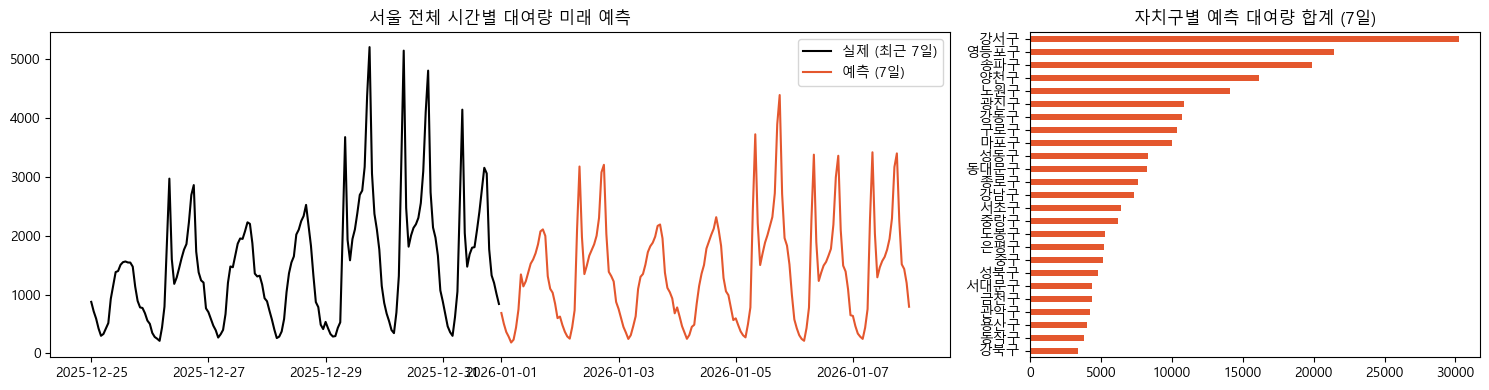

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4), gridspec_kw={"width_ratios": [2, 1]})
past_total = pivot_all.sum(axis=1).iloc[-24 * 7:]
future_total = forecast_gu.groupby("일시")["pred"].sum()
axes[0].plot(past_total.index, past_total.values, color="black", label="실제 (최근 7일)")
axes[0].plot(future_total.index, future_total.values, color="#e4572e", label=f"예측 ({FORECAST_DAYS}일)")
axes[0].set_title("서울 전체 시간별 대여량 미래 예측")
axes[0].legend()
gu_daily.groupby("자치구")["pred"].sum().sort_values().plot(kind="barh", ax=axes[1], color="#e4572e")
axes[1].set_title(f"자치구별 예측 대여량 합계 ({FORECAST_DAYS}일)")
axes[1].set_ylabel("")
save_fig("11_미래예측.png")

## 8. 웹페이지용 저장
1. **web_model.pkl**: 모델 + 예측 재료. `web_predictor.py`가 이 파일로 바로 예측합니다. (예보를 넣어 다시 예측 가능)
2. **forecast_for_web.json**: 이미 계산한 예측 결과. 서버 없이 화면에 바로 표시할 때 사용합니다.

JSON 구조
```
{
  "base_date": 마지막 실제 데이터 날짜,
  "dates": [예측 날짜들],
  "weather": {"강남구": [{"날짜", "평균기온", "강수량", "출처"}, ...]},
  "gu_list": [자치구 목록],
  "data": {
    "강남구": {
      "daily": [날짜별 하루 합계],
      "hourly": [[0시~23시], [0시~23시], ...],
      "stations": [{"name": 대여소명, "daily": [날짜별 하루 합계]}]
    }
  }
}
```

In [ ]:
web_bundle = {
    "model": final_model,
    "model_name": best_name,
    "features": FEATURES,
    "gu_codes": gu_codes,
    "history": history,
    "weather_normals": normals,
    "last_rain": last_rain,
    "holidays": HOLIDAYS,
    "station_share": share_now,
}
joblib.dump(web_bundle, os.path.join(OUTPUT_DIR, "web_model.pkl"))


def make_web_json(forecast_gu, forecast_station, future_weather):
    dates = sorted(forecast_gu["날짜"].unique())
    date_str = [str(pd.Timestamp(d).date()) for d in dates]
    result = {
        "base_date": str(history.index.max().date()),
        "model": best_name,
        "dates": date_str,
        "weather": {},
        "gu_list": sorted(forecast_gu["자치구"].unique()),
        "data": {},
    }
    for gu, part in forecast_gu.groupby("자치구"):
        hourly = part.pivot(index="날짜", columns="시간", values="pred").loc[dates]
        st = forecast_station[forecast_station["자치구"] == gu]
        st = st.groupby(["대여소명", "날짜"])["pred"].sum().unstack().reindex(columns=dates).fillna(0)
        st = st.loc[st.sum(axis=1).sort_values(ascending=False).index]
        result["data"][gu] = {
            "daily": [int(round(v)) for v in hourly.sum(axis=1)],
            "hourly": [[round(float(v), 1) for v in row] for row in hourly.values],
            "stations": [{"name": name, "daily": [int(round(v)) for v in row]} for name, row in st.iterrows()],
        }
        w = future_weather[future_weather["자치구"] == gu]
        result["weather"][gu] = [
            {"날짜": d, "평균기온": round(float(t), 1), "강수량": round(float(r), 1), "출처": s}
            for d, t, r, s in zip(date_str, w["평균기온"], w["강수량"], w["출처"])
        ]
    return result


web_json = make_web_json(forecast_gu, forecast_station, future_weather)
with open(os.path.join(OUTPUT_DIR, "forecast_for_web.json"), "w", encoding="utf-8") as fp:
    json.dump(web_json, fp, ensure_ascii=False)

first_gu = web_json["gu_list"][0]
print("저장 완료: web_model.pkl, forecast_for_web.json")
print(f"예시) {first_gu} 하루 합계:", web_json["data"][first_gu]["daily"])
print(f"예시) {first_gu} 대여소 1위:", web_json["data"][first_gu]["stations"][0])